# Multimodal LLM Finetuning จากชุดข้อมูล Visual Question Answering ภาพถ่ายทางดาวเทียม

ในโน้ตบุ๊กนี้ เราจะดำเนินการเตรียมชุดข้อมูล **VQA (Visual Question Answering)** จากชุดข้อมูล `NuTonic/sat-vl-sft-training-ready-v1` ที่โฮสต์อยู่บน Hugging Face

เป้าหมายคือเพื่อใช้ในการ Fine-tuning โมเดลภาษาขนาดใหญ่ (LLM) สำหรับงานตอบคำถามจากภาพถ่ายดาวเทียม เพื่อนำไป
* **LoRA Fine-tuning** ด้วย Unsloth
* **Inferencing** ด้วย vLLM
* **Evaluation** ประเมินผลลัพธ์ด้วยชุดข้อมูลทดสอบ

## ขั้นตอนที่ 1: การตั้งค่าสภาพแวดล้อม (Setup & Initialization)

### 1.1 การติดตั้งไลบรารีที่จำเป็น

เริ่มต้นด้วยการติดตั้งไลบรารี Python ที่จำเป็นสำหรับการจัดการชุดข้อมูล, การจัดการไฟล์บน Hugging Face Hub, การประมวลผลรูปภาพ, การแสดงผลกราฟ และการแสดงความคืบหน้า

In [2]:
!pip install -U huggingface_hub pillow matplotlib tqdm

ติดตั้ง Library สำหรับการเทรนผ่าน Unsloth

In [25]:
import os
!pip install --upgrade -qqq uv
!uv pip install unsloth unsloth_zoo

Using Python 3.12.13 environment at: /usr
Resolved 99 packages in 196ms
Uninstalled 10 packages in 318ms
Installed 10 packages in 219ms
 - cuda-bindings==13.2.0
 + cuda-bindings==12.9.4
 - datasets==4.8.5
 + datasets==4.3.0
 - dill==0.4.1
 + dill==0.4.0
 - fsspec==2026.2.0
 + fsspec==2025.9.0
 - multiprocess==0.70.19
 + multiprocess==0.70.16
 - torch==2.12.0
 + torch==2.10.0
 - torchvision==0.27.0
 + torchvision==0.25.0
 - transformers==5.8.1
 + transformers==5.5.0
 - triton==3.7.0
 + triton==3.6.0
 - trl==1.4.0
 + trl==0.24.0


In [7]:
!pip install -U torchcodec datasets

  Using cached torchcodec-0.12.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached torchcodec-0.12.0-cp312-cp312-manylinux_2_28_x86_64.whl (2.4 MB)
  Attempting uninstall: torchcodec
    Found existing installation: torchcodec 0.7.0
    Uninstalling torchcodec-0.7.0:
      Successfully uninstalled torchcodec-0.7.0


### 1.2 การเข้าสู่ระบบ Hugging Face Hub

หากต้องการดาวน์โหลดไฟล์ส่วนตัวหรืออัปโหลดโมเดล/ชุดข้อมูลไปยัง Hugging Face Hub คุณจะต้องเข้าสู่ระบบโดยใช้ Hugging Face Access Token

> **Tip:** สามารถเก็บไว้ใน Google Colab Secrets (ตั้งชื่อว่า `HF_Token`) เพื่อความปลอดภัย.

In [1]:
from huggingface_hub import login
from google.colab import userdata
hf_token = userdata.get('HF_Token')
login(hf_token)

### 1.3 การนำเข้าไลบรารี

นำเข้าโมดูลและฟังก์ชันที่จำเป็นทั้งหมดที่เราจะใช้ในโน้ตบุ๊กนี้ รวมถึง `load_dataset` จาก `datasets`, `hf_hub_download` จาก `huggingface_hub`, `Image` จาก `PIL` สำหรับการจัดการรูปภาพ, `matplotlib.pyplot` สำหรับการแสดงผล และ `tqdm` สำหรับแถบความคืบหน้า

In [2]:
from datasets import load_dataset, DatasetDict
from huggingface_hub import hf_hub_download
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import io

## ขั้นตอนที่ 2: การเตรียมและประมวลผลข้อมูล (Data Preparation & Processing)

### 2.1 การโหลดชุดข้อมูลต้นฉบับ

เราจะโหลดชุดข้อมูล `NuTonic/sat-vl-sft-training-ready-v1` โดยตรงจาก Hugging Face Hub ชุดข้อมูลนี้ถูกออกแบบมาเพื่อการ Fine-tuning แบบ SFT (Supervised Fine-Tuning) สำหรับโมเดล Multi-modal LLM และมีข้อมูลในรูปแบบ `messages` ที่คล้ายกับรูปแบบการสนทนาของ Chatbot.

In [7]:
ds = load_dataset("NuTonic/sat-vl-sft-training-ready-v1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


### 2.2 การสำรวจโครงสร้างชุดข้อมูลและตัวอย่าง

หลังจากโหลดชุดข้อมูลแล้ว สิ่งสำคัญคือต้องทำความเข้าใจโครงสร้างของมัน เราจะดูว่าชุดข้อมูลมี `split` อะไรบ้าง (เช่น `train`, `validation`, `test`) และตรวจสอบโครงสร้างของตัวอย่างแรกใน `split` 'train' เพื่อทำความเข้าใจว่าข้อมูล `messages` และ `metadata` ถูกจัดเก็บอย่างไร.

โครงสร้าง `messages` มักจะเป็นลิสต์ของ `dict` ที่มี `role` (เช่น `user`, `assistant`) และ `content` ซึ่งอาจเป็นข้อความหรือข้อมูลรูปภาพ.

In [8]:
print(ds)

sample = ds["train"][0]
print(sample.keys())
print(sample["messages"])
print(sample["metadata"])

DatasetDict({
    train: Dataset({
        features: ['messages', 'metadata', '_postprocess'],
        num_rows: 701272
    })
    validation: Dataset({
        features: ['messages', 'metadata', '_postprocess'],
        num_rows: 53018
    })
    test: Dataset({
        features: ['messages', 'metadata', '_postprocess'],
        num_rows: 53388
    })
})
dict_keys(['messages', 'metadata', '_postprocess'])
[{'role': 'system', 'content': [{'type': 'text', 'text': 'You are a geospatial analyst specializing in satellite imagery interpretation. Analyze the provided Sentinel-2 satellite images and report findings grounded in visible evidence. Use [x1, y1, x2, y2] bounding boxes normalized to 0-1 relative to image dimensions. This is optical-only observation. Avoid certainty claims beyond visible evidence, and state confidence and limitations where appropriate. You receive Sentinel-2 imagery plus a compact provided analytics JSON block (provided signals). Write an analytical summary grounded

### 2.3 ฟังก์ชันช่วยเหลือสำหรับการแปลง VQA

ชุดข้อมูลต้นฉบับอยู่ในรูปแบบการสนทนา เพื่อให้ง่ายต่อการนำไปใช้กับโมเดล VQA ทั่วไป เราจะสร้างฟังก์ชันช่วยเหลือ (`extract_text`, `extract_image_path`, `convert_sample_to_vqa`) เพื่อแยกคำถาม, คำตอบ และที่อยู่รูปภาพ ออกจากโครงสร้าง `messages` และแปลงให้อยู่ในรูปแบบ VQA ที่เรียบง่าย (`id`, `image`, `question`, `answer`, `metadata`).

In [3]:
def extract_text(content):
    if isinstance(content, str):
        return content.strip()

    if isinstance(content, list):
        texts = []
        for item in content:
            if isinstance(item, dict):
                if item.get("type") == "text":
                    texts.append(item.get("text", ""))
                elif "text" in item:
                    texts.append(item["text"])
            elif isinstance(item, str):
                texts.append(item)

        return "\n".join(texts).strip()

    return ""

def extract_image_path(content):
  if isinstance(content, list):
      for item in content:
          if not isinstance(item, dict):
              continue

          if item.get("type") == "image":
              for key in ["image", "path", "image_url"]:
                  if key in item:
                      return item[key]

          for key in ["image", "path", "image_url"]:
              if key in item:
                  return item[key]

  return None

def convert_sample_to_vqa(example, idx=None):
    messages = example["messages"]

    question = None
    answer = None
    image = None

    for msg in messages:
        role = msg.get("role")
        content = msg.get("content")

        if role in ["user", "human"]:
            question = extract_text(content)
            image = extract_image_path(content)

        elif role in ["assistant", "gpt"]:
            answer = extract_text(content)

    return {
        "id": idx,
        "image": image,
        "question": question,
        "answer": answer,
        "metadata": example.get("metadata"),
    }

### 2.4 การแปลงชุดข้อมูลเป็นรูปแบบ VQA

เราจะใช้ฟังก์ชัน `convert_sample_to_vqa` ที่สร้างขึ้นเพื่อประมวลผลชุดข้อมูลต้นฉบับทั้งหมด และแปลงแต่ละ `split` ให้เป็นรูปแบบ VQA ใหม่ (`vqa_ds`) ในกระบวนการนี้ เราจะใช้ `.map()` เพื่อประยุกต์ฟังก์ชันแปลงกับแต่ละตัวอย่าง และ `.filter()` เพื่อลบตัวอย่างที่ไม่สมบูรณ์ (เช่น ไม่มีรูปภาพ, คำถาม หรือคำตอบ).

In [10]:
vqa_ds = DatasetDict()

for split_name in ds.keys():
    print(f"Processing split: {split_name}")

    converted = ds[split_name].map(
        lambda example, idx: convert_sample_to_vqa(example, idx),
        with_indices=True,
        remove_columns=ds[split_name].column_names,
    )

    converted = converted.filter(
        lambda x: x["image"] is not None
        and x["question"] is not None
        and x["answer"] is not None
        and len(x["question"]) > 0
        and len(x["answer"]) > 0
    )

    vqa_ds[split_name] = converted

vqa_ds

Processing split: train
Processing split: validation
Processing split: test


DatasetDict({
    train: Dataset({
        features: ['metadata', 'id', 'image', 'question', 'answer'],
        num_rows: 701272
    })
    validation: Dataset({
        features: ['metadata', 'id', 'image', 'question', 'answer'],
        num_rows: 53018
    })
    test: Dataset({
        features: ['metadata', 'id', 'image', 'question', 'answer'],
        num_rows: 53388
    })
})

### 2.5 การตรวจสอบตัวอย่างชุดข้อมูล VQA ที่แปลงแล้ว

หลังจากแปลงชุดข้อมูลแล้ว เราจะแสดงตัวอย่างแรกจาก `split` 'train' ของ `vqa_ds` เพื่อยืนยันว่าการแปลงเป็นไปอย่างถูกต้อง และข้อมูล (ที่อยู่รูปภาพ, คำถาม, คำตอบ) ถูกแยกออกมาตามที่เราต้องการ.

In [11]:
sample = vqa_ds["train"][0]

print("Image path:", sample["image"])
print("Question:", sample["question"])
print("Answer:", sample["answer"])

Image path: images/NuTonic__sat-bbox-metadata-sft-v1/s00000/poi_000000_g004_t0000.png
Question: Review the provided satellite imagery and the provided analytics JSON. Use the JSON as auxiliary context, and put any comparisons or change interpretation in your response.

Provided analytics JSON:
{"tim_modality_outputs":{"LULC":{"internal_key":"tok_lulc@224","kind":"class_logits","shape":[224,224],"class_fractions":{"trees":0.6468,"grass":0.052,"flooded_vegetation":0.0062,"crops":0.0268,"shrub_and_scrub":0.0219,"built":0.2434,"bare_ground":0.0009,"snow_and_ice":0.002},"classes":{"sample":[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,2.0,2.0,4.0]}},"tok_lulc@224":{"kind":"token_grid","sample":[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,2.0,2.0,4.0],"shape":[224,224]},"Coordinates":{"kind":"coordinates_wgs84","latitude":34.80713904623947,"longitude"

### 2.6 ฟังก์ชันช่วยเหลือสำหรับการดาวน์โหลดและจัดการรูปภาพ

เพื่อให้สามารถแสดงรูปภาพที่เกี่ยวข้องกับ VQA ได้ เราจำเป็นต้องมีฟังก์ชันที่สามารถดาวน์โหลดรูปภาพจาก Hugging Face Hub โดยใช้ `hf_hub_download` และจัดการกับโครงสร้างที่อยู่ไฟล์ (`normalize_image_path`) ชุดข้อมูลนี้มีที่อยู่รูปภาพในรูปแบบเฉพาะ ดังนั้นฟังก์ชัน `normalize_image_path` จะช่วยปรับที่อยู่ให้ถูกต้องก่อนดาวน์โหลด.

In [4]:
from huggingface_hub import hf_hub_download
from PIL import Image
import matplotlib.pyplot as plt

REPO_ID = "NuTonic/sat-vl-sft-training-ready-v1"

def normalize_image_path(image_path):
    parts = image_path.split("/")

    # Check if the path has at least two parts and the second part starts with 'NuTonic__'
    if len(parts) > 1 and parts[1].startswith("NuTonic__"):
        # Reconstruct the path by keeping the first part (e.g., 'images', 'mapbox_stills')
        # and then skipping the second part (the 'NuTonic__' directory), joining the rest.
        image_path = parts[0] + "/" + "/".join(parts[2:])

    return image_path


def download_hf_image(image_path):
    image_path = normalize_image_path(image_path)

    return hf_hub_download(
        repo_id=REPO_ID,
        repo_type="dataset",
        filename=image_path,
    )

### 2.7 การแสดงตัวอย่าง VQA หลายตัวอย่าง

เพื่อแสดงให้เห็นถึงความหลากหลายของชุดข้อมูล VQA เราจะสุ่มเลือกตัวอย่างหลายๆ ตัวจาก `split` 'train' และแสดงรูปภาพ, คำถาม และคำตอบที่เกี่ยวข้อง รูปภาพจะถูกดาวน์โหลดแบบชั่วคราวและแสดงผลโดยใช้ Matplotlib.

images/s00006/poi_010792_t0000.png:   0%|          | 0.00/96.4k [00:00<?, ?B/s]

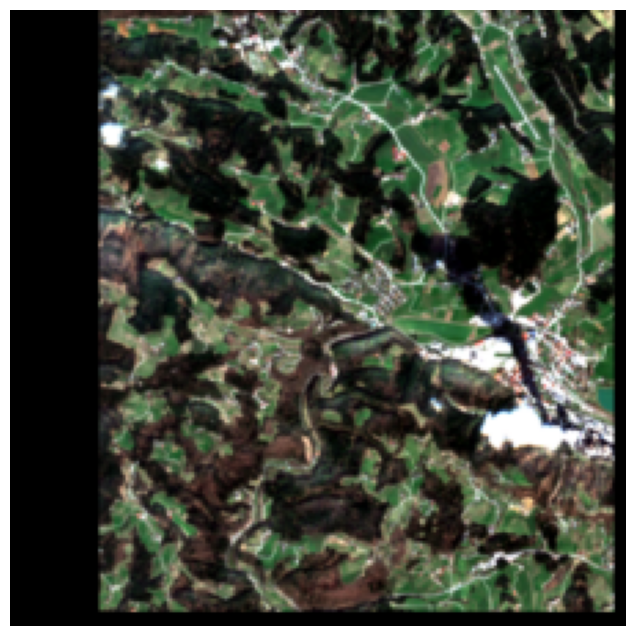

Index: 691512
Question: The input is satellite imagery. Inspect it and detect the shrub and scrub. Provide result as a valid JSON: [{"label": str, "bbox": [x1,y1,x2,y2]}, ...]. Coordinates must be normalized to 0-1.
Answer: [{"label": "shrub and scrub", "bbox": [0.8571, 0.7589, 0.9777, 0.8348]}, {"label": "shrub and scrub", "bbox": [0.5, 0.9152, 0.5893, 0.9688]}, {"label": "shrub and scrub", "bbox": [0.4732, 0.4911, 0.5848, 0.5491]}, {"label": "shrub and scrub", "bbox": [0.567, 0.808, 0.6429, 0.8884]}, {"label": "shrub and scrub", "bbox": [0.3571, 0.7857, 0.4196, 0.8839]}, {"label": "shrub and scrub", "bbox": [0.4554, 0.5625, 0.5179, 0.6161]}, {"label": "shrub and scrub", "bbox": [0.1964, 0.1562, 0.3036, 0.2143]}, {"label": "shrub and scrub", "bbox": [0.7009, 0.7188, 0.7946, 0.7723]}, {"label": "shrub and scrub", "bbox": [0.4152, 0.692, 0.4554, 0.7277]}, {"label": "shrub and scrub", "bbox": [0.4598, 0.6964, 0.4955, 0.75]}, {"label": "shrub and scrub", "bbox": [0.433, 0.3929, 0.5089, 0.

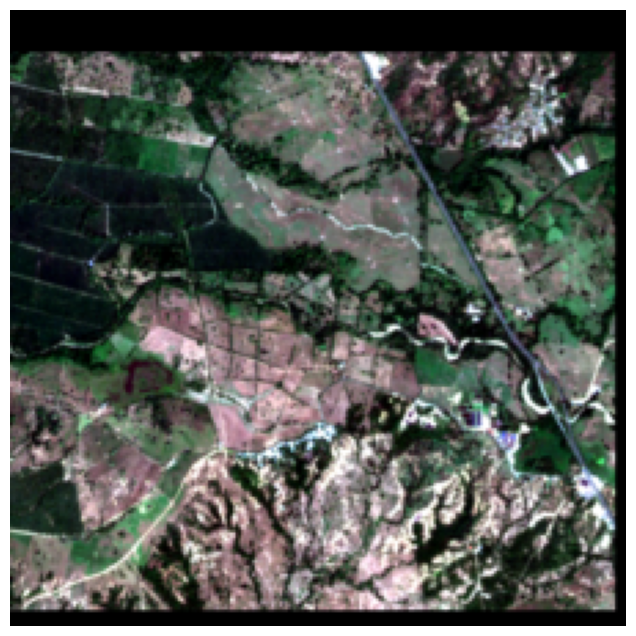

Index: 217718
Question: Review the satellite image and its aligned land-cover label. Describe only tree cover in the imagery: approximate share of valid pixels and brief spatial layout.
Answer: tree cover covers about ~55% of valid pixels in the label raster at this resolution; spatially it appears as one or more contiguous patches.
--------------------------------------------------------------------------------


mapbox_stills/s00006/poi_008028_g003.png:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

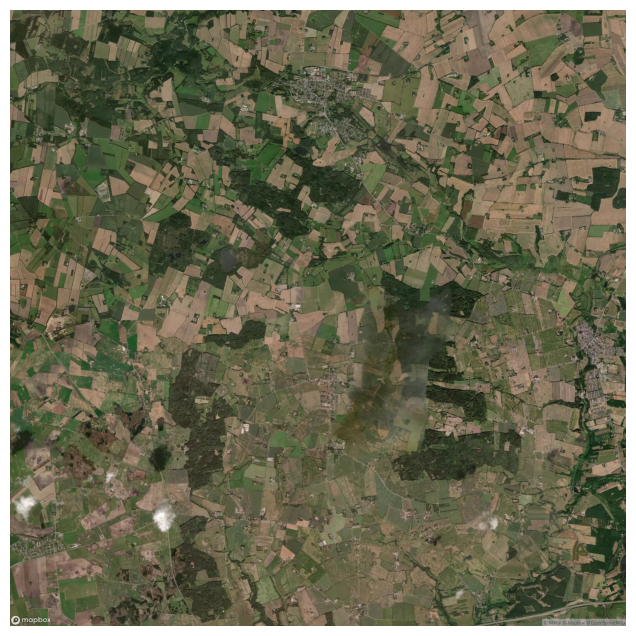

Index: 584302
Question: The input is overhead context imagery (not the same sensor as the chips). Describe it and relate it to the paired satellite imagery and land-cover outputs from the same area in this dataset.
Answer: Overhead context imagery (zoom 12.0) centered near an unspecified location. Pairs with satellite imagery and land-cover outputs from the same area.
--------------------------------------------------------------------------------


In [13]:
# แสดงหลายตัวอย่าง
import random

for _ in range(3):
    idx = random.randint(0, len(vqa_ds["train"]) - 1)
    sample = vqa_ds["train"][idx]

    local_img_path = download_hf_image(sample["image"])
    img = Image.open(local_img_path)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("Index:", idx)
    print("Question:", sample["question"])
    print("Answer:", sample["answer"])
    print("-" * 80)

### 2.8 การบันทึกชุดข้อมูล VQA ลงดิสก์

เพื่อหลีกเลี่ยงการประมวลผลชุดข้อมูลใหม่ทุกครั้งที่รันโน้ตบุ๊ก เราจะบันทึกชุดข้อมูล `vqa_ds` ที่แปลงแล้วลงในดิสก์ในรูปแบบที่ `datasets` สามารถโหลดกลับมาใช้ใหม่ได้ สิ่งนี้ช่วยประหยัดเวลาและทรัพยากร.

In [14]:
vqa_ds.save_to_disk("sat_vl_vqa_dataset")

Saving the dataset (0/2 shards):   0%|          | 0/701272 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/53018 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/53388 [00:00<?, ? examples/s]

เมื่อชุดข้อมูลถูกบันทึกลงดิสก์แล้ว เราสามารถโหลดกลับมาใช้ใหม่ได้อย่างง่ายดายโดยใช้ `load_from_disk` สิ่งนี้มีประโยชน์อย่างยิ่งหากเราปิด Colab Session ไปแล้วและต้องการทำงานต่อจากจุดที่เราบันทึกไว้.

In [5]:
from datasets import load_from_disk

vqa_ds = load_from_disk("sat_vl_vqa_dataset")
vqa_ds

DatasetDict({
    train: Dataset({
        features: ['metadata', 'id', 'image', 'question', 'answer'],
        num_rows: 701272
    })
    validation: Dataset({
        features: ['metadata', 'id', 'image', 'question', 'answer'],
        num_rows: 53018
    })
    test: Dataset({
        features: ['metadata', 'id', 'image', 'question', 'answer'],
        num_rows: 53388
    })
})

## ขั้นตอนที่ 3: การสร้างโมเดลและแปลงชุดข้อมูล


### 3.1 การสร้างโมเดล (Model Initialization)

ส่วนนี้จะถูกใช้สำหรับการ Fine-tuning โมเดลภาษาขนาดใหญ่ (LLM) ด้วยเทคนิค LoRA โดยใช้ไลบรารี Unsloth ที่ได้รับการปรับปรุงประสิทธิภาพ ซึ่งจะช่วยให้การ Fine-tuning ทำได้เร็วขึ้นและใช้หน่วยความจำน้อยลง.

จะใช้ `train` และ `validation` split ของชุดข้อมูล VQA ที่เราเตรียมไว้สำหรับการฝึกอบรมและตรวจสอบประสิทธิภาพระหว่างการฝึก.

In [3]:
!apt-get update -qq
!apt-get install -y -qq ffmpeg libavcodec-dev libavformat-dev libswscale-dev libavutil-dev
!uv pip install --upgrade torchcodec

from unsloth import FastVisionModel
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-4B-Instruct-unsloth-bnb-4bit",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Using Python 3.12.13 environment at: /usr
Resolved 1 package in 73ms
Prepared 1 package in 39ms
Uninstalled 1 package in 1ms
Installed 1 package in 3ms
 - torchcodec==0.7.0
 + torchcodec==0.12.0


/tmp/ipykernel_181839/1754098751.py:5: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastVisionModel


==((====))==  Unsloth 2026.5.2: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

In [4]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r = 128,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

### 3.2 การแปลงชุดข้อมูลให้อยู่ในรูปแบบ Chat Template


In [5]:
def convert_to_conversation(sample):
    # sample["image"] currently holds the Hugging Face dataset internal path
    original_image_path = sample["image"]

    # Download the image using our helper and get the local cached path
    # This will be slow for the entire dataset
    local_image_path = download_hf_image(original_image_path)

    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : sample["question"]},
            # Use the local_image_path obtained from download_hf_image
            {"type" : "image", "image" : local_image_path} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["answer"]} ]
        },
    ]
    return { "messages" : conversation }

In [ ]:
from datasets import concatenate_datasets

# Define the sampling percentage
SAMPLE_PERCENTAGE = 0.007 # 7%

# Concatenate train and validation
train_val_dataset = concatenate_datasets([vqa_ds["train"], vqa_ds["validation"]])

# Sample the training data
num_train_samples = int(len(train_val_dataset) * SAMPLE_PERCENTAGE)
train_dataset_sampled = train_val_dataset.shuffle(seed=42).select(range(num_train_samples))

# Sample the test data
num_test_samples = int(len(vqa_ds["test"]) * SAMPLE_PERCENTAGE)
test_dataset_sampled = vqa_ds["test"].shuffle(seed=42).select(range(num_test_samples))


dataset = {
    "train": train_dataset_sampled,
    "test": test_dataset_sampled,
}

In [21]:
converted_dataset = {}
for split_name, ds_split in dataset.items():
    # Re-run map to apply the updated convert_to_conversation function
    print(f"Converting {split_name} split with updated image paths...")
    converted_dataset[split_name] = ds_split.map(convert_to_conversation, remove_columns=ds_split.column_names)

print("Dataset conversion complete. You can now try trainer.train() again.")

Converting train split with updated image paths...


Parameter 'function'=<function convert_to_conversation at 0x7ad2cc213f60> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only shown once. Subsequent hashing failures won't be shown.


Map:   0%|          | 0/5280 [00:00<?, ? examples/s]

Converting test split with updated image paths...


Map:   0%|          | 0/373 [00:00<?, ? examples/s]

...

images/s00002/poi_003932_g003_t0000.png:   0%|          | 0.00/121k [00:00<?, ?B/s]

images/s00004/poi_007413_g005_t0000.png:   0%|          | 0.00/120k [00:00<?, ?B/s]

images/s00000/poi_000135_g002_t0000.png:   0%|          | 0.00/81.3k [00:00<?, ?B/s]

images/s00003/poi_005615_t0000.png:   0%|          | 0.00/118k [00:00<?, ?B/s]

Dataset conversion complete. You can now try trainer.train() again.


In [22]:
converted_dataset['train'][0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'The input is satellite imagery. Inspect it and detect the built areas land-cover regions. Provide result as a valid JSON: [{"label": str, "bbox": [x1,y1,x2,y2]}, ...]. Coordinates must be normalized to 0-1.'},
    {'type': 'image',
     'image': '/root/.cache/huggingface/hub/datasets--NuTonic--sat-vl-sft-training-ready-v1/snapshots/60d90abd5967ca192b641743a6fe3116380ad212/images/s00003/poi_005387_g005_t0000.png'}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '[{"label": "built areas", "bbox": [0.7946, 0.0982, 0.9955, 0.4018]}, {"label": "built areas", "bbox": [0.9196, 0.4464, 0.9821, 0.5402]}, {"label": "built areas", "bbox": [0.2812, 0.5759, 0.3884, 0.6473]}, {"label": "built areas", "bbox": [0.7098, 0.0, 0.8214, 0.0982]}, {"label": "built areas", "bbox": [0.8839, 0.6339, 0.9554, 0.7054]}, {"label": "built areas", "bbox": [0.5804, 0.3929, 0.6205, 0.4955]}, {"label": "built areas", "b

In [6]:
from datasets import load_from_disk

# Load the converted dataset from disk
loaded_converted_dataset = {}
for split_name in ["train", "test"]:
    loaded_converted_dataset[split_name] = load_from_disk(f"sat_vl_vqa_converted_{split_name}_dataset")

# You can now use loaded_converted_dataset for training
print("Loaded converted dataset:")
print(loaded_converted_dataset)

Loaded converted dataset:
{'train': Dataset({
    features: ['messages'],
    num_rows: 5280
}), 'test': Dataset({
    features: ['messages'],
    num_rows: 373
})}


In [10]:
converted_dataset = loaded_converted_dataset

## ขั้นตอนที่ 4: การทำ LoRA Fine-tuning LLM ด้วย Unsloth

ส่วนนี้จะถูกใช้สำหรับการ Fine-tuning โมเดลภาษาขนาดใหญ่ (LLM) ด้วยเทคนิค LoRA โดยใช้ไลบรารี Unsloth ที่ได้รับการปรับปรุงประสิทธิภาพ ซึ่งจะช่วยให้การ Fine-tuning ทำได้เร็วขึ้นและใช้หน่วยความจำน้อยลง.


### 4.2 Model Training

In [11]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset['train'], # Fixed: Pass the 'train' split
    args = SFTConfig(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 16,
        warmup_ratio = 0.05,
        num_train_epochs = 2,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        save_strategy = "epoch",
        output_dir = './mllm-satellite',
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        report_to = "tensorboard",
        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Model does not have a default image size - using 512


In [12]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,280 | Num Epochs = 2 | Total steps = 660
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 314,572,800 of 4,752,388,608 (6.62% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,1.493456
2,3.065118
3,1.395978
4,1.977546
5,1.167617
6,1.736909
7,1.440104
8,1.369903
9,1.268275
10,1.449546


Unsloth: Restored added_tokens_decoder metadata in ./mllm-satellite/checkpoint-330/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./mllm-satellite/checkpoint-660/tokenizer_config.json.


In [ ]:
import gc
import torch
from unsloth import FastVisionModel

# Aggressively free up memory from previous training or vLLM inference
try:
    del model
    del trainer
except NameError:
    pass

try:
    del llm
    from vllm.distributed.parallel_state import destroy_model_parallel
    destroy_model_parallel()
except Exception:
    pass

# Force garbage collection and empty CUDA cache
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

your_repo_id = "your_username/qwen3-vl-satellite-vqa"
checkpoint_path = "mllm-satellite/checkpoint-660"

print(f"Loading model from local checkpoint: {checkpoint_path}...")
# Load the fine-tuned LoRA adapter from the checkpoint in 16-bit mode for merging
model, tokenizer = FastVisionModel.from_pretrained(
    checkpoint_path,
    load_in_4bit=False, # MUST be False to merge into a 16-bit model
)

print("Saving merged model to local disk in 16-bit format to prevent upload timeouts/OOMs...")
# Use save_pretrained_merged to merge the LoRA adapter into the base model locally first
model.save_pretrained_merged(
    "local_merged_model",
    tokenizer,
    save_method="merged_16bit", # Merges LoRA into the base model and saves as 16-bit
)
print("Successfully saved merged model locally!")


Loading model from local checkpoint: mllm-satellite/checkpoint-660...
==((====))==  Unsloth 2026.5.2: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

Saving merged model to local disk in 16-bit format to prevent upload timeouts/OOMs...


Unsloth: Restored added_tokens_decoder metadata in local_merged_model/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


...

Checking cache directory for required files...



Unsloth: Copying 2 files from cache to `local_merged_model`:   0%|          | 0/2 [00:00<?, ?it/s]
Unsloth: Copying 2 files from cache to `local_merged_model`:  50%|█████     | 1/2 [00:12<00:12, 12.37s/it]
Unsloth: Copying 2 files from cache to `local_merged_model`: 100%|██████████| 2/2 [00:22<00:00, 11.41s/it]


Successfully copied all 2 files from cache to `local_merged_model`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.



Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [00:00<00:00, 15169.27it/s]

Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [00:27<00:00, 13.54s/it]


Unsloth: Merge process complete. Saved to `/content/local_merged_model`
Successfully saved merged model locally!


In [26]:
model.push_to_hub_merged(
    your_repo_id,
    tokenizer,
    save_method="merged_16bit",
    token=hf_token,
)

No files have been modified since last commit. Skipping to prevent empty commit.
Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpyu1ug3z7/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpyu1ug3z7/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0002-of-00002.safetensors:   0%|          | 9.61kB / 3.91GB            


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [02:46<00:00, 83.38s/it]


Unsloth: Merge process complete. Saved to `/tmp/tmpyu1ug3z7`


## ขั้นตอนที่ 5: การประเมินผลโมเดล (Model Evaluation)

### 5.1 การติดตั้งไลบรารีสำหรับการประเมินผล
เพื่อวัดประสิทธิภาพของโมเดลที่เราเทรนเสร็จแล้ว เราจะใช้ไลบรารีเพิ่มเติม เช่น `evaluate`, `rouge_score` และ `bert_score` สำหรับการคำนวณหาค่า Exact Match, Token F1, ROUGE-L และ BERTScore

In [27]:
!pip install -q evaluate rouge_score bert_score vllm

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.2/248.2 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 156.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━

ใน Google colab แนะนำให้ restart session ก่อน inference ใน block ต่อไป

### 5.2 การประเมินผลด้วยชุดข้อมูลทดสอบ (Test Split) ด้วย vLLM
ในขั้นตอนนี้ เราจะรันโมเดลในโหมด Inference ประสิทธิภาพสูงด้วย `vLLM` จากนั้นให้โมเดลทำนายคำตอบจากชุดข้อมูลทดสอบ (Test Set) และนำไปเปรียบเทียบกับคำตอบจริง (Ground Truth) เพื่อคำนวณคะแนนตัวชี้วัดต่างๆ (หากต้องรีสตาร์ทรันไทม์หลังจากติดตั้ง vLLM โค้ดจะโหลดข้อมูลจากดิสก์ให้โดยอัตโนมัติ)

In [1]:
import os
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"

import evaluate
import torch
import gc
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
from collections import Counter
from datasets import load_from_disk
from vllm import LLM, SamplingParams

# 1. Load the converted dataset from disk (in case of session restart)
try:
    converted_dataset
except NameError:
    print("Loading converted dataset from disk...")
    converted_dataset = {}
    for split_name in ["train", "test"]:
        converted_dataset[split_name] = load_from_disk(f"sat_vl_vqa_converted_{split_name}_dataset")

test_dataset = converted_dataset["test"]

# 2. Load Hugging Face Metrics
exact_match_metric = evaluate.load("exact_match")
rouge_metric = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")

def compute_token_f1(predictions, references):
    f1_scores = []
    for pred, ref in zip(predictions, references):
        pred_tokens = pred.lower().split()
        ref_tokens = ref.lower().split()
        common = Counter(pred_tokens) & Counter(ref_tokens)
        num_same = sum(common.values())
        if num_same == 0:
            f1_scores.append(0.0)
            continue
        precision = 1.0 * num_same / len(pred_tokens)
        recall = 1.0 * num_same / len(ref_tokens)
        f1 = (2 * precision * recall) / (precision + recall)
        f1_scores.append(f1)
    return np.mean(f1_scores) if f1_scores else 0.0

# 3. Setup Model for Inference with vLLM
try:
    del model
except NameError:
    pass

try:
    del llm
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

# Use the local model path instead of the Hugging Face Hub ID
model_id = "local_merged_model"

# Fix the tokenizer regex warning before loading into vLLM
try:
    from transformers import AutoTokenizer
    print("Patching tokenizer to fix regex warning...")
    temp_tokenizer = AutoTokenizer.from_pretrained(model_id, fix_mistral_regex=True, trust_remote_code=True)
    temp_tokenizer.save_pretrained(model_id)
    del temp_tokenizer
except Exception as e:
    print("Tokenizer patch skipped:", e)

llm = LLM(
    model=model_id,
    tensor_parallel_size=1,
    max_model_len=8192, # Increased from 4096 to handle larger images/prompts
    gpu_memory_utilization=0.70, # Lowered to prevent fragmentation issues
    enforce_eager=True, # Bypasses some memory allocation issues
    trust_remote_code=True,
    dtype="bfloat16",
    max_num_seqs=4,
    limit_mm_per_prompt={"image": 1}
)
tokenizer = llm.get_tokenizer()

inputs_for_vllm = []
references = []

print(f"Preparing {len(test_dataset)} samples for evaluation...")
for sample in test_dataset:
    messages = sample["messages"]

    # Ground Truth
    ground_truth = messages[-1]["content"][0]["text"]
    references.append(ground_truth)

    # Prepare input
    input_messages = messages[:-1]
    img_obj = None
    for msg in input_messages:
        for content in msg.get("content", []):
            if content.get("type") == "image":
                img_path = content.get("image")
                img_obj = Image.open(img_path) if isinstance(img_path, str) else img_path

    prompt_text = tokenizer.apply_chat_template(
        input_messages,
        add_generation_prompt=True,
        tokenize=False
    )

    inputs_for_vllm.append({
        "prompt": prompt_text,
        "multi_modal_data": {"image": img_obj}
    })

sampling_params = SamplingParams(
    temperature=0.0,
    top_p=1.0,
    max_tokens=128,
)

print("Running vLLM inference...")
outputs = llm.generate(inputs_for_vllm, sampling_params)

predictions = []
for o in outputs:
    predictions.append(o.outputs[0].text.strip())

# 4. Compute all metrics
print("\nCalculating Exact Match...")
em_results = exact_match_metric.compute(predictions=predictions, references=references)

print("Calculating Token F1...")
token_f1_result = compute_token_f1(predictions, references)

print("Calculating ROUGE...")
rouge_results = rouge_metric.compute(predictions=predictions, references=references)

print("Calculating BERTScore...")
bertscore_results = bertscore_metric.compute(predictions=predictions, references=references, lang="en")

# 5. Display Results
print("\n" + "="*40)
print("EVALUATION RESULTS (vLLM)")
print("="*40)
print(f"Exact Match : {em_results.get('exact_match', 0.0):.4f}")
print(f"Token F1    : {token_f1_result:.4f}")
print(f"ROUGE-L     : {rouge_results.get('rougeL', 0.0):.4f}")
print(f"BERTScore   : {np.mean(bertscore_results.get('f1', [0.0])):.4f} (Mean F1)")
print("="*40)


Loading converted dataset from disk...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Patching tokenizer to fix regex warning...
INFO 05-16 15:55:38 [utils.py:240] non-default args: {'trust_remote_code': True, 'dtype': 'bfloat16', 'max_model_len': 8192, 'gpu_memory_utilization': 0.7, 'max_num_seqs': 4, 'disable_log_stats': True, 'enforce_eager': True, 'limit_mm_per_prompt': {'image': 1}, 'model': 'local_merged_model'}
INFO 05-16 15:55:38 [model.py:568] Resolved architecture: Qwen3VLForConditionalGeneration
INFO 05-16 15:55:38 [model.py:1697] Using max model len 8192
INFO 05-16 15:55:38 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 05-16 15:55:38 [vllm.py:886] Asynchronous scheduling is enabled.
WARNING 05-16 15:55:38 [vllm.py:942] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 05-16 15:55:38 [vllm.py:960] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
I

[transformers] `Qwen2VLImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Qwen2VLImageProcessor` instead.
[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


Preparing 373 samples for evaluation...
Running vLLM inference...


...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



EVALUATION RESULTS (vLLM)
Exact Match : 0.1796
Token F1    : 0.5998
ROUGE-L     : 0.6128
BERTScore   : 0.9539 (Mean F1)


### 5.3 การแสดงตัวอย่างผลลัพธ์ 5 ตัวอย่าง (Visualizing Samples)
ลองสุ่มผลลัพธ์จากการทำนายของโมเดลจำนวน 5 ตัวอย่าง เพื่อเปรียบเทียบคำตอบที่โมเดลสร้างขึ้น (Predicted) กับคำตอบจริง (Ground Truth) พร้อมดูภาพถ่ายดาวเทียมที่เกี่ยวข้อง


 Question 1 (Index in Test Set: 152)


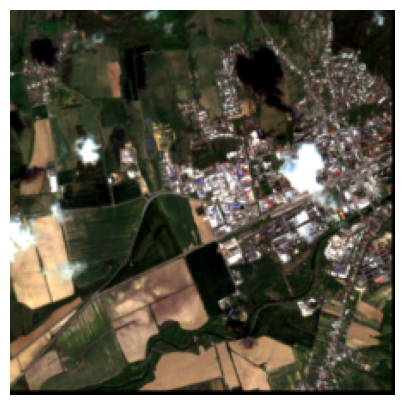

[Question]     : The input is satellite imagery. Inspect it and detect the cropland. Provide result as a valid JSON: [{"label": str, "bbox": [x1,y1,x2,y2]}, ...]. Coordinates must be normalized to 0-1.
[Ground Truth] : [{"label": "cropland", "bbox": [0.0, 0.2321, 0.5759, 0.9821]}, {"label": "cropland", "bbox": [0.3438, 0.7589, 0.8571, 0.9821]}, {"label": "cropland", "bbox": [0.25, 0.0893, 0.3705, 0.2857]}, {"label": "cropland", "bbox": [0.875, 0.7054, 0.9866, 0.875]}, {"label": "cropland", "bbox": [0.433, 0.1964, 0.4732, 0.2321]}, {"label": "cropland", "bbox": [0.0, 0.1652, 0.0446, 0.2054]}, {"label": "cropland", "bbox": [0.3705, 0.2946, 0.4062, 0.3438]}, {"label": "cropland", "bbox": [0.0536, 0.4509, 0.0759, 0.4777]}]
[Predicted]    : [{"label": "cropland", "bbox": [0.0, 0.0, 0.9955, 0.9866]}, {"label": "cropland", "bbox": [0.0, 0.0, 0.0804, 0.1205]}, {"label": "cropland", "bbox": [0.0, 0.0, 0.0446, 0.0804]}, {"label": "cropland", "bbox": [0.0,

 Question 2 (Index in Test Set: 334)


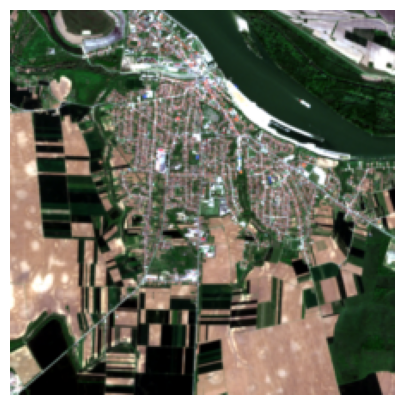

[Question]     : The input is satellite imagery (RGB). Describe this imagery in detail, including surface cover and structure where visible.
[Ground Truth] : This satellite imagery is dominated by cropland (~45%), built areas (~25%), tree cover (~20%), and bare ground (<1%).
[Predicted]    : This satellite imagery is dominated by built areas (~40%), cropland (~30%), tree cover (~15%), and grassland (~5%).

 Question 3 (Index in Test Set: 132)


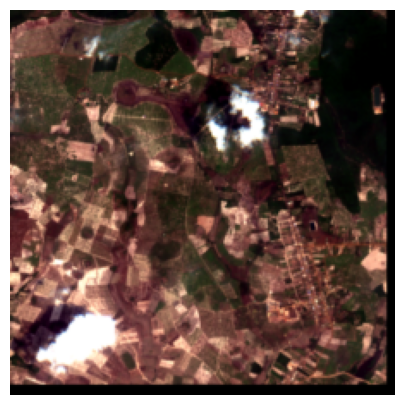

[Question]     : The input is satellite imagery. Inspect it and detect the tree cover. Provide result as a valid JSON: [{"label": str, "bbox": [x1,y1,x2,y2]}, ...]. Coordinates must be normalized to 0-1.
[Ground Truth] : [{"label": "tree cover", "bbox": [0.3616, 0.3929, 0.6652, 0.8304]}, {"label": "tree cover", "bbox": [0.7455, 0.5848, 0.9732, 0.9688]}, {"label": "tree cover", "bbox": [0.692, 0.0, 0.9732, 0.2098]}, {"label": "tree cover", "bbox": [0.0, 0.3348, 0.2321, 0.5402]}, {"label": "tree cover", "bbox": [0.7143, 0.2946, 0.9732, 0.442]}, {"label": "tree cover", "bbox": [0.0, 0.25, 0.2188, 0.3438]}, {"label": "tree cover", "bbox": [0.25, 0.3304, 0.3304, 0.5982]}, {"label": "tree cover", "bbox": [0.4375, 0.0, 0.5536, 0.0714]}, {"label": "tree cover", "bbox": [0.6429, 0.5045, 0.7009, 0.6027]}, {"label": "tree cover", "bbox": [0.5, 0.8795, 0.5804, 0.9688]}, {"label": "tree cover", "bbox": [0.6652, 0.8884, 0.7277, 0.9688]}, {"label": "tree cover", "bbox": [0.625, 0.058, 0.6875, 0.1116]

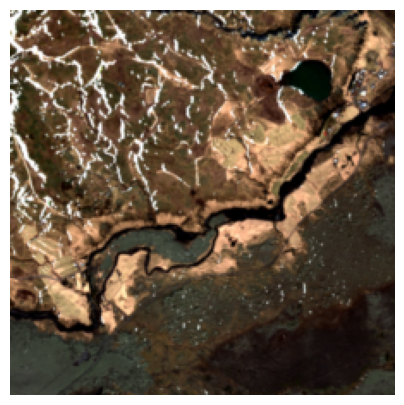

[Question]     : Review the satellite image and its aligned land-cover label. Describe only snow and ice in the imagery: approximate share of valid pixels and brief spatial layout.
[Ground Truth] : In this satellite imagery, snow and ice accounts for about ~15% of valid pixels, showing many small fragments across the tile.
[Predicted]    : In this satellite imagery, snow and ice accounts for about ~10% of valid pixels, showing many small fragments across the tile.

 Question 5 (Index in Test Set: 79)


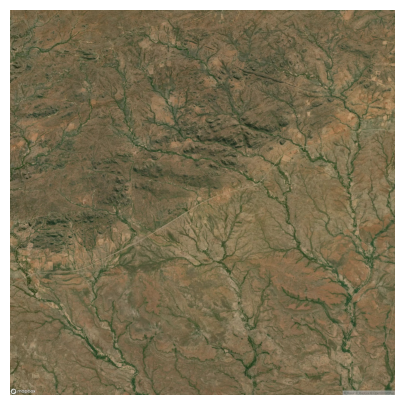

[Question]     : The input is overhead context imagery (not the same sensor as the chips). Describe it and relate it to the paired satellite imagery and land-cover outputs from the same area in this dataset.
[Ground Truth] : Overhead context imagery (zoom 12.0) centered near an unspecified location. Pairs with satellite imagery and land-cover outputs from the same area.
[Predicted]    : Overhead context imagery (zoom 12.0) centered near an unspecified location. Pairs with satellite imagery and land-cover outputs from the same area.


In [4]:
import random
import matplotlib.pyplot as plt
from PIL import Image

if len(predictions) > 0 and len(references) > 0:
    num_samples = min(5, len(predictions))
    # สุ่ม index ของตัวอย่าง
    sample_indices = random.sample(range(len(predictions)), num_samples)

    for i, idx in enumerate(sample_indices):
        print(f"\n Question {i+1} (Index in Test Set: {idx})")

        # ดึงข้อมูลจากชุดทดสอบ
        sample = test_dataset[idx]
        messages = sample["messages"]

        # ค้นหาและโหลดรูปภาพเพื่อแสดงผล รวมถึงข้อความคำถาม
        img_obj = None
        question_text = ""
        for msg in messages[:-1]:
            for content in msg.get("content", []):
                if content.get("type") == "image":
                    img_path = content.get("image")
                    if isinstance(img_path, str):
                        img_obj = Image.open(img_path)
                    else:
                        img_obj = img_path # กรณีโหลดเป็น PIL Image ไว้แล้ว
                elif content.get("type") == "text":
                    question_text = content.get("text", "")

        # แสดงผลรูปภาพ
        if img_obj:
            plt.figure(figsize=(5, 5))
            plt.imshow(img_obj)
            plt.axis("off")
            plt.show()

        # แสดงคำถามและคำตอบ
        print(f"[Question]     : {question_text}")
        print(f"[Ground Truth] : {references[idx]}")
        print(f"[Predicted]    : {predictions[idx]}")
        print("=" * 80)
else:
    print("ไม่พบข้อมูล predictions หรือ references กรุณารันเซลล์ประเมินผลก่อนหน้า")